In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [3]:

df_lifestyle = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df_lifestyle.drop(columns=["HighChol","CholCheck","Stroke","HeartDiseaseorAttack","AnyHealthcare","NoDocbcCost","GenHlth","MentHlth","DiffWalk","Education","Income"], inplace=True)
df_lifestyle.info()
df_lifestyle.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Diabetes_binary    70692 non-null  float64
 1   HighBP             70692 non-null  float64
 2   BMI                70692 non-null  float64
 3   Smoker             70692 non-null  float64
 4   PhysActivity       70692 non-null  float64
 5   Fruits             70692 non-null  float64
 6   Veggies            70692 non-null  float64
 7   HvyAlcoholConsump  70692 non-null  float64
 8   PhysHlth           70692 non-null  float64
 9   Sex                70692 non-null  float64
 10  Age                70692 non-null  float64
dtypes: float64(11)
memory usage: 5.9 MB


,Diabetes_binary,HighBP,BMI,Smoker,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,PhysHlth,Sex,Age
0,0.0,1.0,26.0,0.0,1.0,0.0,1.0,0.0,30.0,1.0,4.0
1,0.0,1.0,26.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,12.0
2,0.0,0.0,26.0,0.0,1.0,1.0,1.0,0.0,10.0,1.0,13.0
3,0.0,1.0,28.0,1.0,1.0,1.0,1.0,0.0,3.0,1.0,11.0
4,0.0,0.0,29.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,8.0


In [22]:
X = df_lifestyle.drop(columns=["Diabetes_binary"])
y = df_lifestyle["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.columns
y.value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [24]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('model', model)
          ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        y_proba = pipe.predict_proba(X_valid)[:, 1]

        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results


🔹 Training Logistic Regression...
ROC-AUC: 0.7923
F1-Score: 0.7310
              precision    recall  f1-score   support

         0.0       0.74      0.70      0.72      7070
         1.0       0.71      0.75      0.73      7069

    accuracy                           0.72     14139
   macro avg       0.72      0.72      0.72     14139
weighted avg       0.72      0.72      0.72     14139



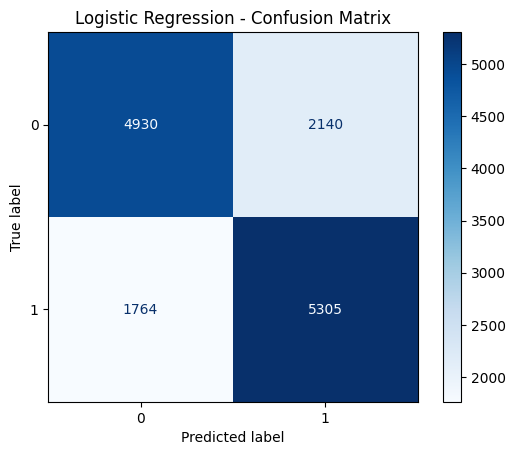


🔹 Training Random Forest...
ROC-AUC: 0.7442
F1-Score: 0.6912
              precision    recall  f1-score   support

         0.0       0.69      0.66      0.68      7070
         1.0       0.68      0.71      0.69      7069

    accuracy                           0.68     14139
   macro avg       0.69      0.68      0.68     14139
weighted avg       0.69      0.68      0.68     14139



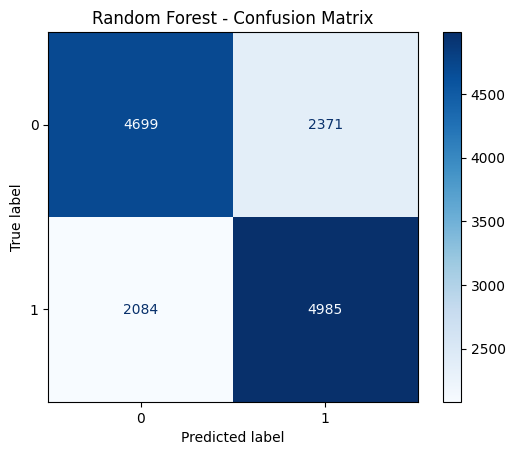


🔹 Training KNN...
ROC-AUC: 0.7381
F1-Score: 0.6899
              precision    recall  f1-score   support

         0.0       0.69      0.67      0.68      7070
         1.0       0.68      0.70      0.69      7069

    accuracy                           0.68     14139
   macro avg       0.68      0.68      0.68     14139
weighted avg       0.68      0.68      0.68     14139



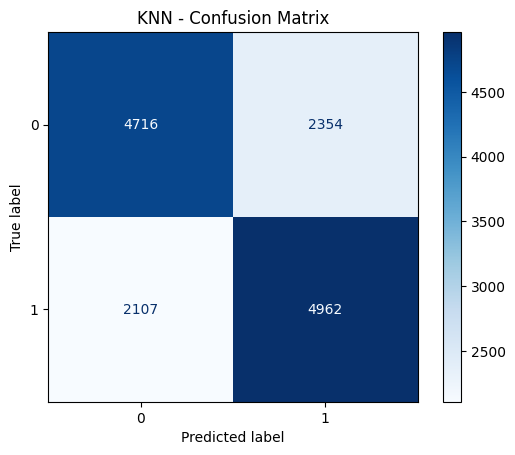


🔹 Training Naive Bayes...
ROC-AUC: 0.7683
F1-Score: 0.7291
              precision    recall  f1-score   support

         0.0       0.74      0.65      0.69      7070
         1.0       0.69      0.77      0.73      7069

    accuracy                           0.71     14139
   macro avg       0.72      0.71      0.71     14139
weighted avg       0.72      0.71      0.71     14139



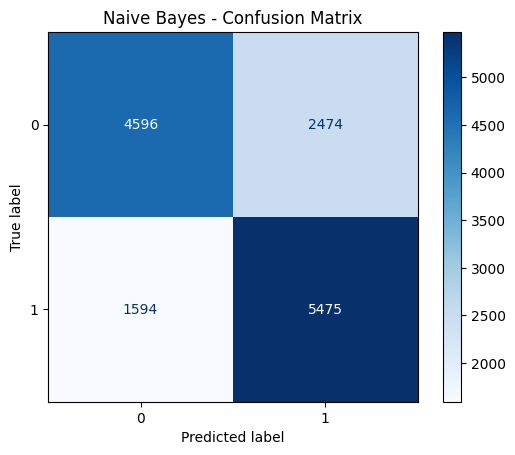


🔹 Training SVM...


In [ ]:
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

In [3]:
df = pd.read_sas("PAQ_L.xpt", format="xport")
df.head()

,SEQN,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680
0,130378.0,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,360.0
1,130379.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,480.0
2,130380.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,240.0
3,130384.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,60.0
4,130385.0,1.000000e+00,b'D',90.0,1.000000e+00,b'W',60.0,180.0


In [ ]:
import pandas as pd

# Function to load XPT file and select only required columns
def load_xpt(filename, columns):
    """
    Load a SAS XPT file using pandas and keep only specific columns.
    """
    df = pd.read_sas(filename, format="xport")
    return df[columns]

# 1️⃣ DEMOGRAPHICS
demo = load_xpt("DEMO_L.XPT", ["SEQN", "RIAGENDR", "RIDAGEYR"])

# 2️⃣ BODY MEASURES
bmx = load_xpt("BMX_L.XPT", ["SEQN", "BMXHT", "BMXWT", "BMXBMI"])

# 3️⃣ PHYSICAL ACTIVITY & SEDENTARY BEHAVIOR
paq = load_xpt(
    "PAQ_L.XPT", 
    [
        "SEQN",
        "PAD790Q",  # exercise_freq_ord
        "PAD790U",  # exercise_duration_ord
        "PAD800",   # sedentary_hours_ord
        "PAD810Q",  # sedentary_hours_ord
        "PAD810U",   # sedentary_hours_ord
        "PAD820",   # sedentary_hours_ord
        "PAD680"   # sedentary_hours_ord
    ]
)
##
#PAD790Q - Frequency of moderate LTPA
#PAD790U - Moderate LTPA unit (day/week/month/year)
#PAD800 - Minutes moderate LTPA
#PAD810Q - Frequency of vigorous LTPA
#PAD810U - Vigorous LTPA unit (day/week/month/year)
#PAD820 - Minutes vigorous LTPA
#PAD680 - Minutes sedentary activity
###
# 4️⃣ DIETARY INTAKE
dr1tot = load_xpt(
    "DR1TOT_L.XPT",
    [
        "SEQN",
        "DR1TSUGR",    # sweets_freq_ord
        "DR1TKCAL"       # sweetdrink/fried/processed proxies
    ]
)

# OPTIONAL: fast food
# dr1iff = load_xpt("datasets/DR1IFF_J.XPT", ["SEQN", "DR1IFF_FASTFOOD"])

# 5️⃣ SLEEP
slq = load_xpt("SLQ_L.XPT", ["SEQN", "SLD012"])  # sleep_ord

# 6️⃣ SMOKING
smq = load_xpt("SMQ_L.XPT", ["SEQN", "SMQ020", "SMQ040"])  # smoking_ord

# 7️⃣ ALCOHOL
alq = load_xpt("ALQ_L.XPT", ["SEQN", "ALQ121", "ALQ130"])  # alcohol_ord

# Merge all datasets on SEQN
dfs = [demo, bmx, paq, dr1tot, slq, smq, alq]
merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="SEQN", how="outer")

# Save final merged dataset to CSV
merged.to_csv("NHANES_Lifestyle_Combined.csv", index=False)
print("Merged CSV file created: NHANES_Lifestyle_Combined.csv")


Merged CSV file created: NHANES_Lifestyle_Combined.csv


In [17]:
df = pd.read_csv("NHANES_Lifestyle_Combined.csv")

df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 529 entries, 1 to 11924
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      529 non-null    float64
 1   RIAGENDR  529 non-null    float64
 2   RIDAGEYR  529 non-null    float64
 3   BMXHT     529 non-null    float64
 4   BMXWT     529 non-null    float64
 5   BMXBMI    529 non-null    float64
 6   PAD790Q   529 non-null    float64
 7   PAD790U   529 non-null    object 
 8   PAD800    529 non-null    float64
 9   PAD810Q   529 non-null    float64
 10  PAD810U   529 non-null    object 
 11  PAD820    529 non-null    float64
 12  PAD680    529 non-null    float64
 13  DR1TSUGR  529 non-null    float64
 14  DR1TKCAL  529 non-null    float64
 15  SLD012    529 non-null    float64
 16  SMQ020    529 non-null    float64
 17  SMQ040    529 non-null    float64
 18  ALQ121    529 non-null    float64
 19  ALQ130    529 non-null    float64
dtypes: float64(18), object(2)
memory us